In [15]:
# 1. 导入必要的库
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import h5py
import random
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import pandas as pd
from einops import rearrange, reduce, repeat
from einops.layers.torch import Rearrange, Reduce
import json
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子以确保可重复性
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [16]:
# 2. 模型定义
class EEGConformer(nn.Module):
    """EEG Conformer 模型适配SEED情感分类数据集"""
    
    def __init__(self, emb_size=40, depth=4, n_classes=3, dropout_rate=0.5, 
                 num_channels=62, time_points=400):
        super(EEGConformer, self).__init__()
        
        # 计算patch数量
        # 经过计算，对于62通道×400时间点，patch数量为79
        num_patches = 79  # 需要根据实际计算
        
        # Patch Embedding - 针对62通道修改
        self.patch_embedding = nn.Sequential(
            nn.Conv2d(1, 40, kernel_size=(1, 13), stride=(1, 1), padding=(0, 6)),
            nn.BatchNorm2d(40),
            nn.ELU(),
            nn.Dropout2d(0.3),
            
            # 修改：卷积核从(22,1)改为(62,1)以适配62通道
            nn.Conv2d(40, 40, kernel_size=(62, 1), stride=(1, 1)),
            nn.BatchNorm2d(40),
            nn.ELU(),
            nn.Dropout2d(0.3),
            
            # 平均池化 - 保持相同设置
            nn.AvgPool2d(kernel_size=(1, 10), stride=(1, 5)),
            nn.Conv2d(40, emb_size, kernel_size=(1, 1)),
            Rearrange('b e (h) (w) -> b (h w) e'),
        )
        
        # 修改：位置编码数量改为实际patch数
        self.position_embedding = nn.Parameter(torch.randn(1, num_patches, emb_size))
        
        # Transformer Encoder
        self.transformer_encoder = nn.ModuleList([
            TransformerBlock(emb_size, num_heads=8, dropout_rate=dropout_rate)
            for _ in range(depth)
        ])
        
        # 分类头
        self.classifier = ClassificationHead(emb_size, n_classes)
        
    def forward(self, x):
        x = self.patch_embedding(x)
        x = x + self.position_embedding[:, :x.size(1), :]
        
        for transformer_block in self.transformer_encoder:
            x = transformer_block(x)
        
        x, logits = self.classifier(x)
        return x, logits


class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size, num_heads, dropout_rate):
        super().__init__()
        self.emb_size = emb_size
        self.num_heads = num_heads
        self.head_dim = emb_size // num_heads
        
        assert self.head_dim * num_heads == emb_size, "emb_size必须能被num_heads整除"
        
        self.q_linear = nn.Linear(emb_size, emb_size)
        self.k_linear = nn.Linear(emb_size, emb_size)
        self.v_linear = nn.Linear(emb_size, emb_size)
        
        self.dropout = nn.Dropout(dropout_rate)
        self.out_linear = nn.Linear(emb_size, emb_size)
        
    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.shape
        
        Q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        K = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        V = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        attention = F.softmax(scores, dim=-1)
        attention = self.dropout(attention)
        
        out = torch.matmul(attention, V)
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.emb_size)
        out = self.out_linear(out)
        
        return out


class TransformerBlock(nn.Module):
    def __init__(self, emb_size, num_heads, dropout_rate, expansion=4):
        super().__init__()
        
        self.attention = nn.Sequential(
            nn.LayerNorm(emb_size),
            MultiHeadAttention(emb_size, num_heads, dropout_rate),
            nn.Dropout(dropout_rate)
        )
        
        self.feed_forward = nn.Sequential(
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size, emb_size * expansion),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(emb_size * expansion, emb_size),
            nn.Dropout(dropout_rate)
        )
        
    def forward(self, x):
        x = x + self.attention(x)
        x = x + self.feed_forward(x)
        return x


# 修改ClassificationHead类
class ClassificationHead(nn.Module):
    def __init__(self, emb_size, n_classes):
        super().__init__()
        
        # 修改1: 移除LayerNorm
        self.global_pool = nn.Sequential(
            # nn.LayerNorm(emb_size),  # 移除这行
            nn.AdaptiveAvgPool1d(1),  # 全局平均池化
            Rearrange('b e 1 -> b e')
        )
        
        # 修改2: 在分类器开头添加LayerNorm
        self.classifier = nn.Sequential(
            nn.LayerNorm(emb_size),  # 添加在这里
            nn.Linear(emb_size, 128),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )
        
    def forward(self, x):
        # x形状: (batch, seq_len, emb_size)
        # 修改3: 正确处理转置
        pooled = self.global_pool(x.transpose(1, 2))  # 转换为 (batch, emb_size, seq_len)
        
        # 分类
        logits = self.classifier(pooled)
        
        return pooled, logits

In [17]:
class H5Dataset(Dataset):
    """加载H5格式的SEED数据集"""
    
    def __init__(self, h5_path, has_labels=True, scaler_mean=None, scaler_std=None):
        self.h5_path = h5_path
        self.has_labels = has_labels
        
        # 加载数据
        with h5py.File(h5_path, 'r') as f:
            print(f"文件 {h5_path} 中的数据集: {list(f.keys())}")
            
            # SEED数据集通常使用'X'和'y'作为键名
            if 'X' in f:
                self.data = f['X'][:]
            elif 'data' in f:
                self.data = f['data'][:]
            elif 'eeg' in f:
                self.data = f['eeg'][:]
            else:
                # 尝试查找其他可能的键名
                for key in f.keys():
                    if key.lower() in ['x', 'data', 'eeg', 'features']:
                        self.data = f[key][:]
                        print(f"使用键名: {key}")
                        break
                else:
                    raise ValueError(f"在 {h5_path} 中未找到数据，可用的键: {list(f.keys())}")
            
            print(f"原始数据形状: {self.data.shape}")
            
            if has_labels:
                if 'y' in f:
                    self.labels = f['y'][:]
                elif 'labels' in f:
                    self.labels = f['labels'][:]
                elif 'label' in f:
                    self.labels = f['label'][:]
                else:
                    # 尝试查找其他可能的标签键名
                    for key in f.keys():
                        if key.lower() in ['y', 'labels', 'label']:
                            self.labels = f[key][:]
                            print(f"使用标签键名: {key}")
                            break
                    else:
                        raise ValueError(f"在 {h5_path} 中未找到标签，可用的键: {list(f.keys())}")
                
                print(f"标签形状: {self.labels.shape}")
                # 确保标签是整数类型
                self.labels = self.labels.astype(int)
                print(f"标签分布: {np.bincount(self.labels.flatten())}")
            else:
                self.labels = None
        
        # 重塑数据格式
        if len(self.data.shape) == 3:  # (samples, channels, time)
            # 假设形状是 (samples, 62, 400)
            self.data = np.expand_dims(self.data, axis=1)  # 添加通道维度: (samples, 1, 62, 400)
        elif len(self.data.shape) == 2:  # (samples, features)
            # SEED: 62通道 * 400时间点 = 24800
            if self.data.shape[1] == 24800:
                self.data = self.data.reshape(-1, 1, 62, 400)
            else:
                # 尝试自动计算
                print(f"数据形状: {self.data.shape}，尝试推断...")
                # 假设是 62通道，计算时间点数
                num_channels = 62
                num_features = self.data.shape[1]
                if num_features % num_channels == 0:
                    time_points = num_features // num_channels
                    self.data = self.data.reshape(-1, 1, num_channels, time_points)
                    print(f"重塑为: (-1, 1, {num_channels}, {time_points})")
                else:
                    print(f"警告: 无法自动推断数据形状")
        
        print(f"重塑后数据形状: {self.data.shape}")
        
        # 使用训练集的统计量进行标准化
        if scaler_mean is not None and scaler_std is not None:
            self.data = (self.data - scaler_mean) / (scaler_std + 1e-8)
            print(f"已使用训练集统计量进行标准化")
            print(f"标准化后 - 均值: {np.mean(self.data):.4f}, 标准差: {np.std(self.data):.4f}")
        else:
            print(f"未进行标准化")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        eeg = torch.FloatTensor(self.data[idx])
        
        if self.has_labels:
            # 确保标签是标量整数
            label = int(self.labels[idx].flatten()[0])
            label = torch.tensor(label, dtype=torch.long)
            return eeg, label
        else:
            return eeg

In [18]:
# 4. 模型训练器
class EEGConformerTrainer:
    def __init__(self, model, device='cuda', lr=1e-4, weight_decay=1e-4):
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(
            model.parameters(), 
            lr=lr, 
            weight_decay=weight_decay
        )
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='max', factor=0.5, patience=5, verbose=True
        )
        
    def train_epoch(self, train_loader):
        """训练一个epoch"""
        self.model.train()
        total_loss = 0
        all_preds = []
        all_labels = []
        
        for batch_idx, (eeg, labels) in enumerate(train_loader):
            eeg, labels = eeg.to(self.device), labels.to(self.device)
            
            # 前向传播
            self.optimizer.zero_grad()
            _, outputs = self.model(eeg)
            loss = self.criterion(outputs, labels)
            
            # 反向传播
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            
            # 记录指标
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        
        epoch_loss = total_loss / len(train_loader)
        epoch_acc = accuracy_score(all_labels, all_preds)
        
        return epoch_loss, epoch_acc
    
    def validate(self, val_loader):

        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
    
        with torch.no_grad():
            for eeg, labels in tqdm(val_loader, desc="验证"):
                eeg, labels = eeg.to(self.device), labels.to(self.device)
            
                _, outputs = self.model(eeg)
                loss = self.criterion(outputs, labels)
            
                total_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
    
        epoch_loss = total_loss / len(val_loader)
        epoch_acc = accuracy_score(all_labels, all_preds)
    
        return epoch_loss, epoch_acc, all_preds, all_labels

    # # 在训练完成后，修改分类报告
    # print("\n验证集分类报告:")
    # print(classification_report(val_labels, val_preds, 
    #                         target_names=['negative', 'neutral', 'positive']))
    # print(f"加权F1分数: {f1_score(val_labels, val_preds, average='weighted'):.4f}")
    
    def predict(self, test_loader):
        """预测（无标签）"""
        self.model.eval()
        all_preds = []
        all_probs = []
        
        with torch.no_grad():
            for eeg in tqdm(test_loader, desc="预测"):
                eeg = eeg.to(self.device)
                
                # 前向传播
                _, outputs = self.model(eeg)
                probs = F.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                
                all_preds.extend(predicted.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
        
        return np.array(all_preds), np.array(all_probs)
    
    def save_model(self, path):
        """保存模型"""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
        }, path)
    
    def load_model(self, path):
        """加载模型"""
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

In [19]:
def train_and_evaluate(train_path, val_path, test_path, config):
    """主训练和评估函数 - 适配SEED数据集"""
    
    # 设置设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")
    
    print("\n" + "="*50)
    print("第一步: 加载训练数据并计算标准化参数...")
    
    # 1. 先加载训练集（不进行标准化）
    train_dataset_raw = H5Dataset(train_path, has_labels=True, scaler_mean=None, scaler_std=None)
    
    # 2. 计算训练集的标准化参数
    # SEED数据形状: (samples, 1, 62, 400)
    train_mean = np.mean(train_dataset_raw.data, axis=(0, 3), keepdims=True)  # 形状: (1, 1, 62, 1)
    train_std = np.std(train_dataset_raw.data, axis=(0, 3), keepdims=True) + 1e-8  # 形状: (1, 1, 62, 1)
    
    print(f"\n训练集标准化参数:")
    print(f"  均值形状: {train_mean.shape}")
    print(f"  标准差形状: {train_std.shape}")
    
    # 3. 用训练集的统计量重新加载所有数据集
    print("\n" + "="*50)
    print("第二步: 用训练集的统计量标准化所有数据...")
    
    train_dataset = H5Dataset(train_path, has_labels=True, scaler_mean=train_mean, scaler_std=train_std)
    val_dataset = H5Dataset(val_path, has_labels=True, scaler_mean=train_mean, scaler_std=train_std)
    test_dataset = H5Dataset(test_path, has_labels=False, scaler_mean=train_mean, scaler_std=train_std)
    
    # 创建数据加载器 - 这是关键修复点！
    train_loader = DataLoader(
        train_dataset, 
        batch_size=config['batch_size'], 
        shuffle=True, 
        num_workers=2,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=config['batch_size'], 
        shuffle=False, 
        num_workers=2
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=config['batch_size'], 
        shuffle=False, 
        num_workers=2
    )
    
    print(f"\n数据加载器创建完成:")
    print(f"  训练集: {len(train_dataset)} 个样本, {len(train_loader)} 个批次")
    print(f"  验证集: {len(val_dataset)} 个样本, {len(val_loader)} 个批次")
    print(f"  测试集: {len(test_dataset)} 个样本, {len(test_loader)} 个批次")
    
    # 4. 创建模型
    model = EEGConformer(
        emb_size=config['emb_size'],
        depth=config['depth'],
        n_classes=config['n_classes'],
        dropout_rate=config['dropout_rate']
    )
    
    # 5. 创建训练器
    trainer = EEGConformerTrainer(
        model, 
        device=device,
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    
    # 6. 训练
    print("\n" + "="*50)
    print("开始训练...")
    
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    
    best_val_acc = 0
    best_epoch = 0
    
    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        print("-" * 30)
        
        # 训练
        train_loss, train_acc = trainer.train_epoch(train_loader)  # 这里使用train_loader
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # 验证
        val_loss, val_acc, val_preds, val_labels = trainer.validate(val_loader)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # 学习率调整
        trainer.scheduler.step(val_acc)
        
        print(f"训练损失: {train_loss:.4f}, 训练准确率: {train_acc:.4f}")
        print(f"验证损失: {val_loss:.4f}, 验证准确率: {val_acc:.4f}")
        
        # 保存最佳模型
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            trainer.save_model('best_model.pth')
            print(f"✓ 保存最佳模型 (验证准确率: {val_acc:.4f})")
    
    # 7. 测试
    print("\n" + "="*50)
    print("测试最佳模型...")
    trainer.load_model('best_model.pth')
    
    # 在验证集上评估最佳模型
    val_loss, val_acc, val_preds, val_labels = trainer.validate(val_loader)
    
    print(f"最终验证结果 - 损失: {val_loss:.4f}, 准确率: {val_acc:.4f}")
    
    # 打印分类报告
    print("\n验证集分类报告:")
    print(classification_report(val_labels, val_preds, target_names=['negative', 'neutral', 'positive']))
    print(f"加权F1分数: {f1_score(val_labels, val_preds, average='weighted'):.4f}")
    
    # 对测试集进行预测
    print("\n" + "="*50)
    print("对测试集进行预测...")
    test_predictions, test_probabilities = trainer.predict(test_loader)
    
    # 保存预测结果
    np.save('test_predictions.npy', test_predictions)
    np.save('test_probabilities.npy', test_probabilities)
    
    # 保存为txt文件
    with open('test_predictions.txt', 'w') as f:
        for pred in test_predictions:
            f.write(f"{int(pred)}\n")
    
    print(f"测试集预测结果已保存:")
    print(f"  - test_predictions.npy: 包含所有预测 (0/1/2)")
    print(f"  - test_probabilities.npy: 包含预测概率")
    print(f"  - test_predictions.txt: 纯文本格式，每行一个预测")
    
    # 打印预测统计
    print(f"\n测试集预测统计:")
    unique, counts = np.unique(test_predictions, return_counts=True)
    label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
    for label, count in zip(unique, counts):
        label_name = label_names.get(label, f'Class_{label}')
        print(f"  {label_name} ({label}): {count} 个样本 ({count/len(test_predictions)*100:.1f}%)")
    
    # 绘制训练曲线
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(train_losses, label='train loss', marker='o', markersize=3)
    axes[0].plot(val_losses, label='val loss', marker='s', markersize=3)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(train_accs, label='train accuracy', marker='o', markersize=3)
    axes[1].plot(val_accs, label='val accuracy', marker='s', markersize=3)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 绘制混淆矩阵
    cm = confusion_matrix(val_labels, val_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No-Reading', 'Reading'], 
                yticklabels=['No-Reading', 'Reading'])
    plt.title('Validation Confusion Matrix')
    plt.ylabel('True Labels')
    plt.xlabel('Predicted Labels')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 8. 保存训练结果汇总
    results = {
        'best_epoch': best_epoch + 1,
        'best_val_accuracy': float(best_val_acc),
        'final_val_accuracy': float(val_acc),
        'final_val_loss': float(val_loss),
        'train_losses': [float(x) for x in train_losses],
        'train_accuracies': [float(x) for x in train_accs],
        'val_losses': [float(x) for x in val_losses],
        'val_accuracies': [float(x) for x in val_accs],
        'test_predictions': test_predictions.tolist(),
        'test_predictions_summary': {
            'total_samples': len(test_predictions),
            'num_negative': int((test_predictions == 0).sum()),
            'num_neutral': int((test_predictions == 1).sum()),
            'num_positive': int((test_predictions == 2).sum()),
            'percentage_negative': float((test_predictions == 0).sum() / len(test_predictions) * 100),
            'percentage_neutral': float((test_predictions == 1).sum() / len(test_predictions) * 100),
            'percentage_positive': float((test_predictions == 2).sum() / len(test_predictions) * 100)
        }
    }
    
    with open('training_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print("\n训练结果已保存到 training_results.json")
    
    return trainer, test_predictions, val_acc, val_loss

EEG Conformer 配置:
  emb_size: 40
  depth: 4
  n_classes: 3
  dropout_rate: 0.3
  batch_size: 64
  learning_rate: 0.0001
  weight_decay: 1e-05
  num_epochs: 30
  num_channels: 62
  time_points: 400
使用设备: cuda

第一步: 加载训练数据并计算标准化参数...
文件 data/SEED/train.h5 中的数据集: ['X', 'y']
原始数据形状: (900, 62, 400)
标签形状: (900,)
标签分布: [300 300 300]
重塑后数据形状: (900, 1, 62, 400)
未进行标准化

训练集标准化参数:
  均值形状: (1, 1, 62, 1)
  标准差形状: (1, 1, 62, 1)

第二步: 用训练集的统计量标准化所有数据...
文件 data/SEED/train.h5 中的数据集: ['X', 'y']
原始数据形状: (900, 62, 400)
标签形状: (900,)
标签分布: [300 300 300]
重塑后数据形状: (900, 1, 62, 400)
已使用训练集统计量进行标准化
标准化后 - 均值: -0.0000, 标准差: 1.0000
文件 data/SEED/val.h5 中的数据集: ['X', 'y']
原始数据形状: (450, 62, 400)
标签形状: (450,)
标签分布: [150 150 150]
重塑后数据形状: (450, 1, 62, 400)
已使用训练集统计量进行标准化
标准化后 - 均值: 0.0002, 标准差: 0.9898
文件 data/SEED/test_x_only.h5 中的数据集: ['X']
原始数据形状: (450, 62, 400)
重塑后数据形状: (450, 1, 62, 400)
已使用训练集统计量进行标准化
标准化后 - 均值: -0.0000, 标准差: 1.0031

数据加载器创建完成:
  训练集: 900 个样本, 15 个批次
  验证集: 450 个样本, 8 个批次
  测试集: 450 个样本, 8 个批次

开始

验证:   0%|          | 0/8 [00:00<?, ?it/s]

训练损失: 1.1242, 训练准确率: 0.3178
验证损失: 1.0939, 验证准确率: 0.3711
✓ 保存最佳模型 (验证准确率: 0.3711)

Epoch 2/30
------------------------------


验证:   0%|          | 0/8 [00:00<?, ?it/s]

训练损失: 1.1107, 训练准确率: 0.3544
验证损失: 1.0846, 验证准确率: 0.3689

Epoch 3/30
------------------------------


...

Epoch 00030: reducing learning rate of group 0 to 1.2500e-05.
训练损失: 1.0071, 训练准确率: 0.4911
验证损失: 1.2172, 验证准确率: 0.3978

测试最佳模型...


验证:   0%|          | 0/8 [00:00<?, ?it/s]

最终验证结果 - 损失: 1.1351, 准确率: 0.4267

验证集分类报告:
              precision    recall  f1-score   support

    negative       0.44      0.73      0.55       150
     neutral       0.43      0.13      0.20       150
    positive       0.41      0.42      0.41       150

    accuracy                           0.43       450
   macro avg       0.43      0.43      0.39       450
weighted avg       0.43      0.43      0.39       450

加权F1分数: 0.3859

对测试集进行预测...


预测:   0%|          | 0/8 [00:00<?, ?it/s]

测试集预测结果已保存:
  - test_predictions.npy: 包含所有预测 (0/1/2)
  - test_probabilities.npy: 包含预测概率
  - test_predictions.txt: 纯文本格式，每行一个预测

测试集预测统计:
  negative (0): 256 个样本 (56.9%)
  neutral (1): 40 个样本 (8.9%)
  positive (2): 154 个样本 (34.2%)


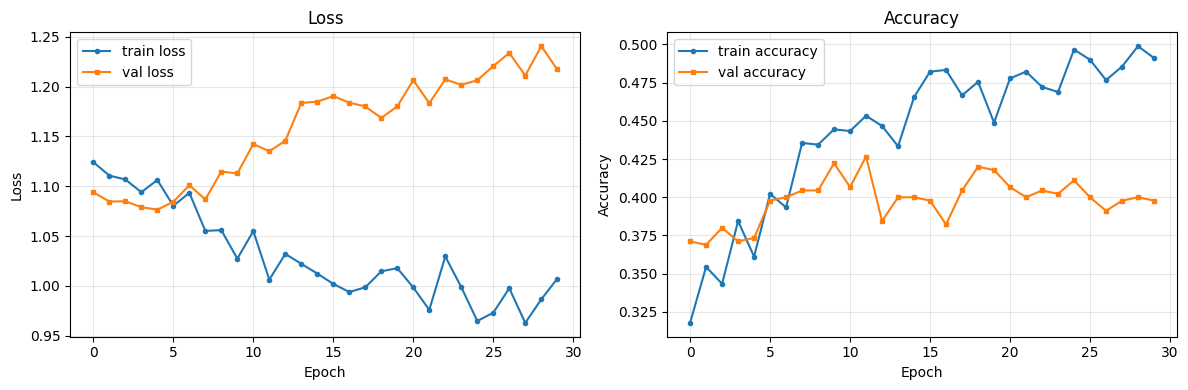

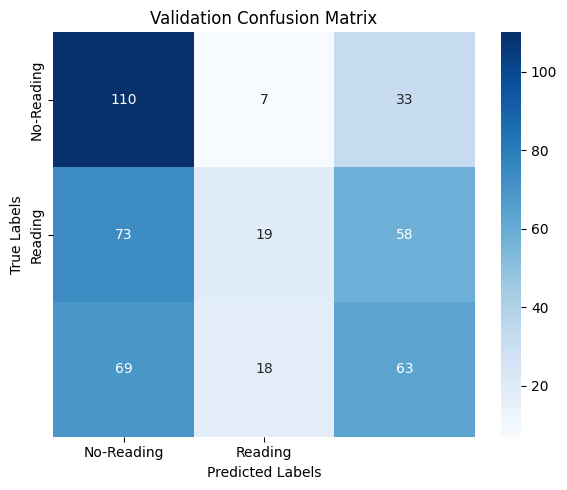


训练结果已保存到 training_results.json

训练完成!
最终验证准确率: 0.4267
最终验证损失: 1.1351
测试集预测已保存到 test_predictions.txt


In [20]:
# 6. 配置和运行
if __name__ == "__main__":
    # 配置参数
    config = {
        'emb_size': 40,           # 嵌入维度
        'depth': 4,              # Transformer层数
        'n_classes': 3,          # 改为3分类
        'dropout_rate': 0.3,     # Dropout比率
        'batch_size': 64,        # 批次大小
        'learning_rate': 1e-4,   # 学习率
        'weight_decay': 1e-5,    # 权重衰减
        'num_epochs': 30,        # 训练轮数
        'num_channels': 62,      # 新增：电极通道数
        'time_points': 400,      # 新增：时间点数
    }
    
    # 打印配置
    print("EEG Conformer 配置:")
    for key, value in config.items():
        print(f"  {key}: {value}")
    

    # 文件路径
    train_path = "data/SEED/train.h5"  # 训练集
    val_path = "data/SEED/val.h5"      # 验证集
    test_path = "data/SEED/test_x_only.h5"  # 测试集（只有特征）
    
    # 训练和评估模型
    try:
        trainer, test_predictions, val_acc, val_loss = train_and_evaluate(
            train_path, val_path, test_path, config
        )
        
        print("\n" + "="*50)
        print("训练完成!")
        print(f"最终验证准确率: {val_acc:.4f}")
        print(f"最终验证损失: {val_loss:.4f}")
        print(f"测试集预测已保存到 test_predictions.txt")
        
    except Exception as e:
        print(f"训练过程中发生错误: {e}")
        import traceback
        traceback.print_exc()

In [21]:
# 7. 辅助函数
def load_predictions():
    """加载预测结果"""
    if os.path.exists('test_predictions.txt'):
        predictions = np.loadtxt('test_predictions.txt', dtype=int)
        print(f"加载了 {len(predictions)} 个预测结果")
        print(f"预测分布: {np.bincount(predictions)}")
        return predictions
    else:
        print("预测文件不存在")
        return None

def visualize_sample_predictions(trainer, test_dataset, num_samples=5):
    """可视化一些测试样本的预测"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainer.model.eval()
    trainer.model.to(device)
    
    # 创建测试数据加载器
    test_loader = DataLoader(test_dataset, batch_size=num_samples, shuffle=True)
    
    # 获取一些样本
    eeg_samples = next(iter(test_loader))
    if isinstance(eeg_samples, tuple):  # 如果有标签
        eeg_samples, _ = eeg_samples
    
    eeg_samples = eeg_samples[:num_samples].to(device)
    
    # 获取预测
    with torch.no_grad():
        _, outputs = trainer.model(eeg_samples)
        probabilities = F.softmax(outputs, dim=1)
        _, predictions = torch.max(outputs, 1)
    
    # 绘制EEG信号和预测结果
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 3*num_samples))
    
    for i in range(min(num_samples, len(eeg_samples))):
        # 绘制EEG信号
        eeg_data = eeg_samples[i, 0].cpu().numpy()
        
        axes[i, 0].imshow(eeg_data, aspect='auto', cmap='RdBu_r', interpolation='none')
        axes[i, 0].set_title(f'测试样本 {i+1}')
        axes[i, 0].set_xlabel('时间点')
        axes[i, 0].set_ylabel('通道')
        plt.colorbar(axes[i, 0].imshow(eeg_data, aspect='auto', cmap='RdBu_r'), ax=axes[i, 0])
        
        # 显示预测结果
        pred_label = 'Reading' if predictions[i].item() == 1 else 'No-Reading'
        prob_reading = probabilities[i, 1].item() * 100
        prob_no_reading = probabilities[i, 0].item() * 100
        
        axes[i, 1].text(0.5, 0.5, 
                       f'预测: {pred_label}\n'
                       f'Reading概率: {prob_reading:.1f}%\n'
                       f'No-Reading概率: {prob_no_reading:.1f}%', 
                       ha='center', va='center', fontsize=10)
        axes[i, 1].axis('off')
        axes[i, 1].set_title('预测结果')
    
    plt.tight_layout()
    plt.show()